# Redes neuronales convolucionales (CNN)

Los dataset <i>MNIST</i> y <i>Fashion MNIST</i> tienen las siguientes características:
<ul>
    <li>Tamaño de imágenes 28x28</li>
    <li>No tienen ruido, es decir, contenido específico </li>
    <li>Escala de grises</li>
</ul>

Desafortunadamente, las imágenes de un problema real no siempre cuentan con esas características, ya que pueden ser de color, de diferentes tamaños y contener información que no pertenece a la clase, entre otras.

En la presente actividad se resolverá un problema de clasificación multiclase mediante una CNN, cuyo *dataset* está compuesto de 10 tipos de imágenes a color.

In [ ]:
import tensorflow as tf
print(tf.__version__)

tf.random.set_seed(42)

2.20.0


In [ ]:
import keras
from keras.datasets import cifar10

## Cargar el dataset cifar 10

In [ ]:
# Se importa el dataset MNIST
cifar10 = cifar10

# Se cargan los conjuntos de entrenamiento (*_train_whole) y de validación (*_test) en variables separadas
(X_train_whole, y_train_whole), (X_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1734s 10us/step


## Visualización de las imágenes del dataset cifar 10

Para la visualización de las imágenes se va a emplear la librería **OpenCV** (*Open Source Computer Vision Library*), que se emplea en visión computacional, procesamiento de imágenes y *machine learning*. **OpenCV** es una librería *open-source*.

Los métodos que se van a ocupar para la visualización del dataset son:
<dd>
    <dl><b>imread</b> Carga una imagen de un archivo. En el caso de las imágenes a color, el orden de los canales es <b>BGR</b></dl>
    <dl><b>resize</b> Cambia el tamaño de una imagen</dl>
    <dl><b>cvtColor</b> Convierte la imagen de <b>BGR</b> a <b>RGB</b></dl>
    <dl><b>imshow</b> Visualiza una imagen</dl>
</dd>

Referencia: https://docs.opencv.org/3.4/index.html

In [ ]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import math

In [ ]:
def display_images(set_img, num_img):
    fig, axes = plt.subplots(1, num_img, figsize=(20, 20))
    axes = axes.flatten()
    for img, ax in zip(set_img, axes):
        ax.imshow(img)
    plt.tight_layout()
    plt.show()

In [ ]:
#Función para graficar resultados del performance
def PlotPerformance(acc, val_acc, loss, val_loss, exp):
    accuracy = acc
    val_accuracy = val_acc
    loss_model = loss
    val_loss_model = val_loss
    Accname = f'{exp} Accuracy'
    Lossname = f'{exp} Loss'

    epochs = range(len(accuracy))

    #------------------------------------------------
    # Accuracy
    #------------------------------------------------

    plt.plot(epochs, accuracy,'b',label='Training accuracy')
    plt.plot(epochs, val_accuracy,'r',label='Validation accuracy')

    plt.title("Accuracy")
    plt.legend()
    plt.figure()

    #------------------------------------------------
    # Loss
    #------------------------------------------------

    plt.plot(epochs, loss_model, 'b', label='Training Loss')
    plt.plot(epochs, val_loss_model, 'r', label='Validation Loss')
    plt.title(Lossname)
    plt.legend()
    plt.show()

In [ ]:
# Función que gráfica las métricas del entrenamiento de varios modelos
def Plot_All_Performance(lst_acc, lst_val_acc, lst_loss, lst_val_loss, lst_exp):
  lst_colors = ['blue', 'red', 'green', 'purple', 'yellow', 'orange', 'pink']

  longest_sublist = max(lst_acc, key=len)
  # Obtiene el número de elementos de la lista más larga
  max_epoch = len(longest_sublist)

  epochs = range(max_epoch)

  ncols = 3
  nrows = math.ceil(len(lst_exp) / ncols)

  #------------------------------------------------
  # Accuracy
  #------------------------------------------------

  fig, ax = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
  ax = ax.flatten()

  for i, exp in enumerate(lst_exp):

    epochs = range(len(lst_acc[i]))


    ax[i].plot(epochs, lst_acc[i], color=lst_colors[i], linestyle='-', label="Accuracy")
    ax[i].plot(epochs, lst_val_acc[i], color=lst_colors[i], linestyle=':', label="Validation accuracy")
    ax[i].set_title(exp)              # Título principal (arriba)
    ax[i].set_xlabel("")              # Elimina etiqueta del eje X
    ax[i].set_ylabel("")              # Elimina etiqueta del eje Y
    ax[i].legend()

  for j in range(i + 1, len(ax)):
      fig.delaxes(ax[j])

  plt.tight_layout()
  plt.show()

  #------------------------------------------------
  # Loss
  #------------------------------------------------

  fig, ax = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
  ax = ax.flatten()

  for i, exp in enumerate(lst_exp):

    epochs = range(len(lst_acc[i]))

    ax[i].plot(epochs, lst_loss[i], color=lst_colors[i], linestyle='-', label="Loss")
    ax[i].plot(epochs, lst_val_loss[i], color=lst_colors[i], linestyle=':', label="Loss validation")
    ax[i].set_title(exp)              # Título principal (arriba)
    ax[i].set_xlabel("")              # Elimina etiqueta del eje X
    ax[i].set_ylabel("")              # Elimina etiqueta del eje Y
    ax[i].legend()

  for j in range(i + 1, len(ax)):
      fig.delaxes(ax[j])

  plt.tight_layout()
  plt.show()

# Preprocesamiento de imágenes

El preprocesamiento de las imágenes es un proceso donde se preparan las imágenes en crudo para posteriormente usarlas en el entrenamiento de un modelo.

Algunas de las técnicas de preprocesamiento de imágenes son:

<ul>
    <li>Normalización</li>
    <li>Redimensionar imágenes</li>
    <li>Reducción de ruido (<i>GaussianBlur</i> y <i>medianBlur</i>)</li>
    <li>Mejorar el contraste</li>
</ul>

El aplicar estás técnicas ayudan a mejorar la precisión de la CNN.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_validation, y_train, y_validation = train_test_split(X_train_whole, y_train_whole,
                                                                stratify=y_train_whole,
                                                                test_size=0.2,
                                                                random_state=42)
print(f'Número de elementos para entrenar {X_train.shape[0]}')
print(f'Número de elementos para validar {X_validation.shape[0]}')

Número de elementos para entrenar 40000
Número de elementos para validar 10000


In [ ]:
print(X_train.shape)
print(X_test.shape)
print(X_validation.shape)

(40000, 32, 32, 3)
(10000, 32, 32, 3)
(10000, 32, 32, 3)


In [ ]:
X_train = X_train/255.0
X_validation = X_validation/255.0
X_test = X_test/255.0

<h2> Visualización de las imágenes de MNIST </h2>

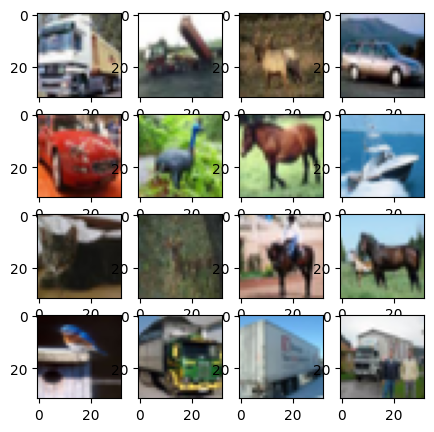

In [ ]:
import matplotlib.pyplot as plt

# Tamaño de la figura
w = 5
h = 5

# Número de columnas y filas del subplot
cols = 4
rows = 4

# Creación de la figura
fig = plt.figure(figsize=(w, h))

for i in range(1, cols*rows+1):
  img = X_train_whole[i]
  fig.add_subplot(rows, cols, i)
  plt.imshow(img)
plt.show()

<h1> Distribución de los datos del dataset </h1>

Text(0, 0.5, 'Valores')

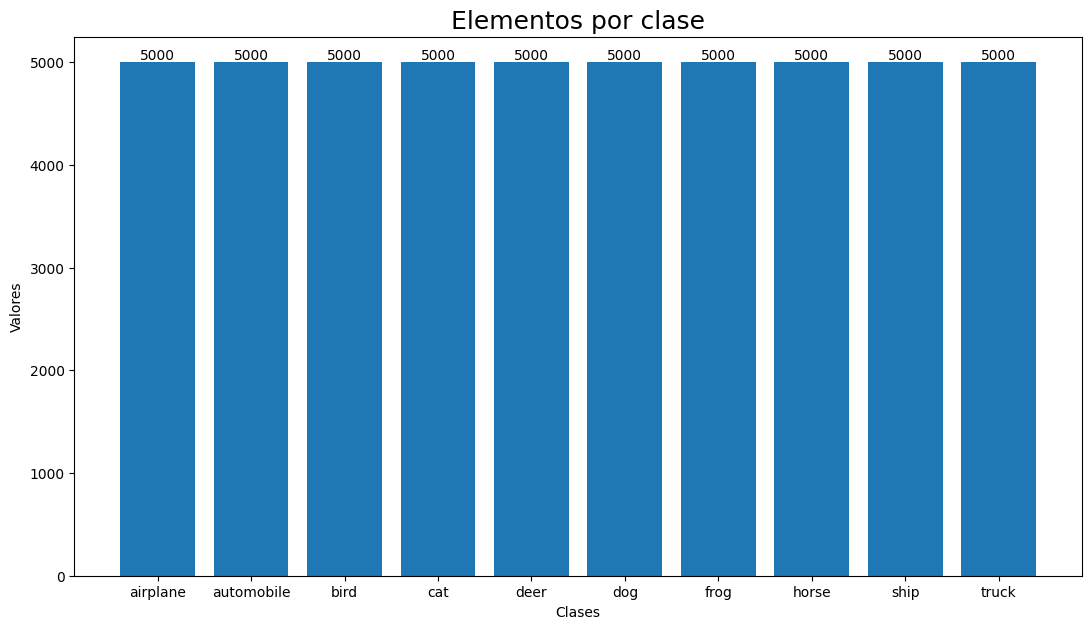

In [ ]:
import numpy as np
clases, valor  = np.unique(y_train_whole, return_counts=True)

# Etiquetas del dataset
labels = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

w = 13
h = 7
plt.figure(figsize=(w,h))

plt.xticks(range(len(labels)))
bars = plt.bar(labels, valor)#, color="green")
for bar in bars:
    # Altura de la barra
    yval = bar.get_height()
    # Texto en la parte superior
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, yval, ha='center', va='bottom')

plt.title("Elementos por clase", fontsize=18)
plt.xlabel('Clases')
plt.ylabel('Valores')

## Definición y entrenamiento de una CNN (convolutional neural network)

In [ ]:
from keras import Sequential
from keras.optimizers import RMSprop, Adam
from keras import regularizers
from keras.layers import Conv2D, MaxPooling2D, GlobalAveragePooling2D, Input
from keras.layers import Dense, BatchNormalization
from keras.layers import Dropout, Activation

### Definición de una CNN

Las capas que se emplean en una CNN son:

<dd>
    <dl><b>Conv2D</b> Una capa convolucional emplea <i>kernels</i> para extraer los <i>features</i> más relevantes. Además, tienen la misma profundidad que una imagen. Los parámetros de esta capa son:</dl>
    <ul>
        <li><b>filters</b> Número entero que indica la dimensión de salida</li>
        <li><b>kernel_size</b> Tamaño del kernel, se puede dar un número entero o una tupla de dos números enteros.</li>
        <li><b>strides</b>= número entero o una tupla de dos números enteros. Indica el desplazamiento del filtro en la imagen.</li>
        <li><b>padding</b>= "same" evita la reducción de la dimensionalidad, "valid" significa no padding </li>
        <li><b>activation</b>= Función de activación </li>
    </ul>
    <dl><b>MaxPooling2D</b> Reduce la imagen de entrada en lo ancho y largo, calculando el valor máximo de la ventana. Lo anterior se lleva a cabo en cada canal de la entrada. Se debe especificar el tamaño de la ventana, ya sea mediante un número entero o una tupla de enteros.</dl>
</dd>

In [ ]:
model = Sequential([
    # La entrada es una imagen de 32 x 32 pixeles en tres canales R,G,B
    Input(shape=(32, 32, 3)),
    Conv2D(32, 3, activation='relu', padding="same"),
    MaxPooling2D(2),
    Conv2D(64, (3,3), activation='relu', padding="same"),
    MaxPooling2D((2,2)),
    Conv2D(128, (3,3), activation='relu', padding="same"),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu', padding="same"),
    MaxPooling2D(2,2),
    # Promedia cada mapa de características a lo largo de las dimensiones espaciales (H y W)
    GlobalAveragePooling2D(),
    # Capa oculta de 512 Neuronas
    Dense(512, activation='relu'),
    # Salida
    Dense(10, activation='softmax')
])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 312,010 (1.19 MB)

 Trainable params: 312,010 (1.19 MB)

 Non-trainable params: 0 (0.00 B)

### Compilar el modelo

In [ ]:
model.compile(optimizer=RMSprop(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics = ['accuracy'])

## Entrenamiento del modelo

Parámetros:
* *validation_steps* se calcula dividiendo el número de muestras del conjunto de validación entre el batch size.
* *steps_per_epoch* se calcula dividiendo el número de muestras del conjunto de entrenamiento entre el batch size.
* *epochs* es el número de iteraciones que se va a entrenar el modelo.

In [ ]:
epochs = 20

In [ ]:
# La variable history guarda el entrenamiento de la CNN
history = model.fit(X_train, y_train,
                    validation_data=(X_validation, y_validation),
                    epochs=epochs,
                    verbose=2)

Epoch 1/20
1250/1250 - 14s - 11ms/step - accuracy: 0.3680 - loss: 1.7032 - val_accuracy: 0.5013 - val_loss: 1.3562
Epoch 2/20
1250/1250 - 6s - 5ms/step - accuracy: 0.5638 - loss: 1.2181 - val_accuracy: 0.6332 - val_loss: 1.0427
Epoch 3/20
1250/1250 - 7s - 5ms/step - accuracy: 0.6538 - loss: 0.9760 - val_accuracy: 0.6672 - val_loss: 0.9551
Epoch 4/20
1250/1250 - 6s - 5ms/step - accuracy: 0.7171 - loss: 0.8101 - val_accuracy: 0.6870 - val_loss: 0.9401
Epoch 5/20
1250/1250 - 7s - 5ms/step - accuracy: 0.7624 - loss: 0.6887 - val_accuracy: 0.7098 - val_loss: 0.9390
Epoch 6/20
1250/1250 - 6s - 5ms/step - accuracy: 0.7956 - loss: 0.5965 - val_accuracy: 0.7119 - val_loss: 0.9786
Epoch 7/20
1250/1250 - 7s - 5ms/step - accuracy: 0.8228 - loss: 0.5189 - val_accuracy: 0.7211 - val_loss: 0.9654
Epoch 8/20
1250/1250 - 6s - 5ms/step - accuracy: 0.8451 - loss: 0.4536 - val_accuracy: 0.7243 - val_loss: 0.9988
Epoch 9/20
1250/1250 - 7s - 5ms/step - accuracy: 0.8603 - loss: 0.4123 - val_accuracy: 0.7235 

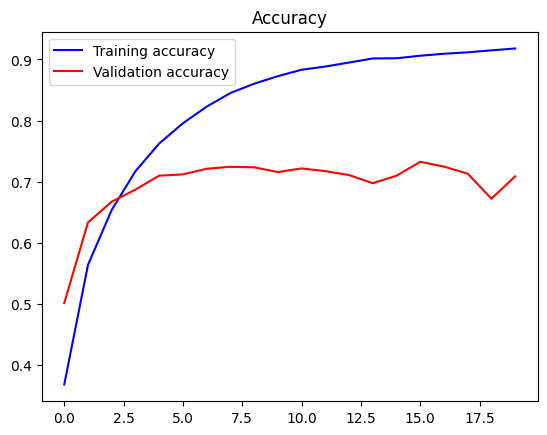

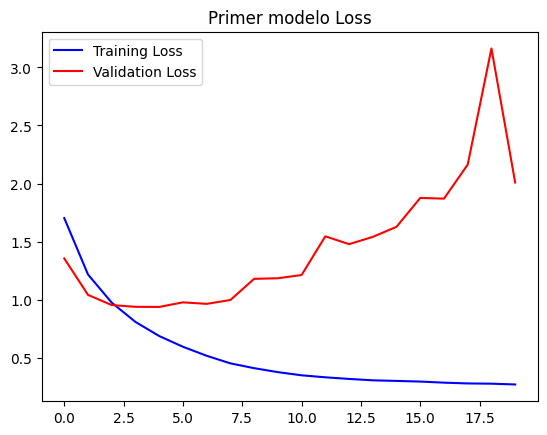

In [ ]:
PlotPerformance(history.history['accuracy'],
                history.history['val_accuracy'],
                history.history['loss'],
                history.history['val_loss'],
                'Primer modelo')

#### Como se puede observar, el modelo reduce su *loss* (error) con los datos en entrenamiento pero en los datos de validación aumenta. Lo anterior indica que el modelo no va a tener un buen desempeño con datos no vistos (nuevos). A este comportamiento se le conoce como **overfitting** o sobreajuste.

<h1>Overfitting</h1>

El *overfitting*, también conocido como **sobreajuste**, se presenta cuando la red neuronal tiene un buen desempeño en el conjunto de entrenamiento pero con datos nuevos, las inferencias son imprecisas, esto es, no tiene capacidad de generalizar.

Las causas del sobreajuste pueden ser:
* El conjunto de entrenamiento es pequeño y no tiene suficiente información para que el modelo aprenda
* El conjunto de entrenamiento contiene información irrelevante
* El número de épocas es muy grande
* La complejidad del modelo es superior al conjunto de datos.

El *overfitting* se puede prevenir con:
* Capa Dropout
* Regularización
* Batch Normalization
* Early stopping
* Data augmentation

In [ ]:
# Inicialización de listas
lst_acc = []
lst_val_acc = []
lst_loss = []
lst_val_loss = []
lst_exp = []

## Capa Dropout

La capa *dropout* desactiva un porcentaje de neuronas en una capa de una red neuronal, las cuales no se toman en cuenta en el proceso de *backpropagation* del entrenamiento de la red.

La explicación de como funciona la capa dropout durante el entrenamiento e inferencias se encuentra en https://towardsdatascience.com/dropout-in-neural-networks-47a162d621d9


In [ ]:
#Definición del modelo
model1 = Sequential([
    Input(shape=(32, 32, 3)),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.2),

    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

#Compilación
model1.compile(optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics = ['accuracy'])

#Entrenamiento
history1 = model1.fit(X_train, y_train,
                    validation_data=(X_validation, y_validation),
                    epochs=epochs,
                    verbose=2)

Epoch 1/20
1250/1250 - 17s - 14ms/step - accuracy: 0.3398 - loss: 1.7293 - val_accuracy: 0.4538 - val_loss: 1.4760
Epoch 2/20
1250/1250 - 8s - 6ms/step - accuracy: 0.5034 - loss: 1.3472 - val_accuracy: 0.5774 - val_loss: 1.1595
Epoch 3/20
1250/1250 - 7s - 6ms/step - accuracy: 0.5676 - loss: 1.1927 - val_accuracy: 0.6076 - val_loss: 1.0904
Epoch 4/20
1250/1250 - 7s - 6ms/step - accuracy: 0.6049 - loss: 1.0931 - val_accuracy: 0.6594 - val_loss: 0.9672
Epoch 5/20
1250/1250 - 7s - 6ms/step - accuracy: 0.6403 - loss: 1.0085 - val_accuracy: 0.6732 - val_loss: 0.9208
Epoch 6/20
1250/1250 - 7s - 5ms/step - accuracy: 0.6626 - loss: 0.9497 - val_accuracy: 0.6954 - val_loss: 0.8724
Epoch 7/20
1250/1250 - 7s - 6ms/step - accuracy: 0.6831 - loss: 0.8957 - val_accuracy: 0.7147 - val_loss: 0.8089
Epoch 8/20
1250/1250 - 7s - 5ms/step - accuracy: 0.6969 - loss: 0.8572 - val_accuracy: 0.7260 - val_loss: 0.7846
Epoch 9/20
1250/1250 - 7s - 6ms/step - accuracy: 0.7092 - loss: 0.8192 - val_accuracy: 0.7287 

In [ ]:
lst_acc.append(history1.history['accuracy'])
lst_val_acc.append(history1.history['val_accuracy'])
lst_loss.append(history1.history['loss'])
lst_val_loss.append(history1.history['val_loss'])
lst_exp.append('Dropout')

## Regularización

La regularización es un método que penaliza la función de pérdida (*loss*) durante el entrenamiento de un modelo. Los tipos de regularización son:
<ol>
    <li>L1 (<i>Regresión Lasso</i>) Suma el valor absoluto de los coeficientes como penalización</li>
    <li>L2 (<i>Regresión Ridge</i>) Suma el cuadrado de los coeficientes como penalización</li>
    <li>L1L2 (<i>Regresión Elastic Net</i>) Suma el cuadrado de los coeficientes como penalización</li>
</ol>
    


In [ ]:
# Definición del modelo
model2 = Sequential(
[
    Input(shape=(32, 32, 3)),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu', kernel_regularizer=regularizers.L2(0.5), padding='same'),
    MaxPooling2D(2,2),
    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dense(10, activation='softmax')
]
)

#Compilación
model2.compile(optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics = ['accuracy']
    )

#Entrenamiento
history2 = model2.fit(X_train, y_train,
                    validation_data=(X_validation, y_validation),
                    epochs=epochs,
                    verbose=2)

Epoch 1/20
1250/1250 - 12s - 10ms/step - accuracy: 0.2262 - loss: 2.7343 - val_accuracy: 0.2816 - val_loss: 1.8623
Epoch 2/20
1250/1250 - 8s - 6ms/step - accuracy: 0.3022 - loss: 1.8227 - val_accuracy: 0.3246 - val_loss: 1.7631
Epoch 3/20
1250/1250 - 7s - 5ms/step - accuracy: 0.3508 - loss: 1.7370 - val_accuracy: 0.3616 - val_loss: 1.6837
Epoch 4/20
1250/1250 - 7s - 6ms/step - accuracy: 0.3719 - loss: 1.6864 - val_accuracy: 0.3876 - val_loss: 1.6394
Epoch 5/20
1250/1250 - 7s - 5ms/step - accuracy: 0.3862 - loss: 1.6505 - val_accuracy: 0.4064 - val_loss: 1.6054
Epoch 6/20
1250/1250 - 7s - 6ms/step - accuracy: 0.4049 - loss: 1.6144 - val_accuracy: 0.4190 - val_loss: 1.5768
Epoch 7/20
1250/1250 - 7s - 5ms/step - accuracy: 0.4322 - loss: 1.5612 - val_accuracy: 0.4350 - val_loss: 1.5337
Epoch 8/20
1250/1250 - 7s - 6ms/step - accuracy: 0.4551 - loss: 1.5039 - val_accuracy: 0.4391 - val_loss: 1.5323
Epoch 9/20
1250/1250 - 6s - 5ms/step - accuracy: 0.4728 - loss: 1.4639 - val_accuracy: 0.4357 

In [ ]:
lst_acc.append(history2.history['accuracy'])
lst_val_acc.append(history2.history['val_accuracy'])
lst_loss.append(history2.history['loss'])
lst_val_loss.append(history2.history['val_loss'])
lst_exp.append('Regularización')

# Batch Normalization

Es una técnica que contribuye a una convergencia más rápida, mejora la estabilidad durante el entrenamiento y favorece la capacidad de generalización del modelo. Esto se logra mediante la normalización de las activaciones de las capas ocultas dentro de cada minibatch. Para ello, calcula la media y la varianza de las activaciones en el minilote y luego normaliza dichas activaciones utilizando estas estadísticas.

***Batch Normalization*** ayuda a estabilizar diversos problemas que suelen presentarse durante el entrenamiento, tales como:

1. El desplazamiento interno de covariables (*internal covariate shift*).
2. La aparición de gradientes desvanecientes (*vanishing*) o explosivos (*exploding*).
3. La alta sensibilidad a la inicialización de los pesos.

In [ ]:
#Definición del modelo
model3 = Sequential([
    Input(shape=(32, 32, 3)),
    Conv2D(64, (3,3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(2, 2),
    Conv2D(128, (3, 3), padding='same'),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(2, 2),
    GlobalAveragePooling2D(),
    Dense(512),
    BatchNormalization(),
    Activation('relu'),
    Dense(10, activation='softmax')
])

#Compilación
model3.compile(optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics = ['accuracy'])

#Entrenamiento
history3 = model3.fit(X_train, y_train,
                    validation_data= (X_validation, y_validation),
                    epochs=epochs,
                    verbose=2)

Epoch 1/20
1250/1250 - 16s - 13ms/step - accuracy: 0.5086 - loss: 1.3664 - val_accuracy: 0.4662 - val_loss: 1.5884
Epoch 2/20
1250/1250 - 16s - 12ms/step - accuracy: 0.6420 - loss: 1.0072 - val_accuracy: 0.5287 - val_loss: 1.4818
Epoch 3/20
1250/1250 - 8s - 7ms/step - accuracy: 0.7035 - loss: 0.8383 - val_accuracy: 0.5703 - val_loss: 1.4535
Epoch 4/20
1250/1250 - 8s - 6ms/step - accuracy: 0.7502 - loss: 0.7139 - val_accuracy: 0.5195 - val_loss: 1.7878
Epoch 5/20
1250/1250 - 8s - 7ms/step - accuracy: 0.7903 - loss: 0.6081 - val_accuracy: 0.4647 - val_loss: 2.3950
Epoch 6/20
1250/1250 - 9s - 7ms/step - accuracy: 0.8210 - loss: 0.5154 - val_accuracy: 0.5606 - val_loss: 1.7019
Epoch 7/20
1250/1250 - 8s - 6ms/step - accuracy: 0.8533 - loss: 0.4307 - val_accuracy: 0.6283 - val_loss: 1.4097
Epoch 8/20
1250/1250 - 8s - 7ms/step - accuracy: 0.8755 - loss: 0.3619 - val_accuracy: 0.5606 - val_loss: 2.0682
Epoch 9/20
1250/1250 - 8s - 6ms/step - accuracy: 0.8971 - loss: 0.2980 - val_accuracy: 0.566

In [ ]:
lst_acc.append(history3.history['accuracy'])
lst_val_acc.append(history3.history['val_accuracy'])
lst_loss.append(history3.history['loss'])
lst_val_loss.append(history3.history['val_loss'])
lst_exp.append('Batch normalization')

# API Callbacks de Keras



Callbacks es una herramienta que permite personalizar el comportamiento de un modelo en diferentes etapas: entrenamiento (<b>model.fit</b>), evaluación (<b>model.evaluate</b>) o inferencias (<b>model.predict</b>).
</br>

<ul>
  <li> <b>EarlyStopping</b> Detiene el entrenamiento cuando se cumple la condición especificada.
  <ul>
    <li>
        <i>monitor</i> Métrica que se va a monitorear. Por default <b>val_loss</b>
    </li>
    <li>
      <i>patience</i> Número de épocas en las que el modelo no mejora durante el entrenamiento.
    </li>
    <li>
      <i>min_delta</i> Valor que indica el cambio mínimo que se espera tenga el modelo.
    </li>
  </ul>
  <li> <b>ModelCheckpoint</b> Salva el modelo después de cada época.
  <table>
    <tr>
      <td> <i>filepath</i> </td>
      <td> string </td>
      <td> Ruta y nombre del modelo <td>
    </tr>
    <tr>
      <td> <i>save_best_only</i> </td>
      <td> bool </td>
      <td> Con <b>true</b> el mejor modelo será almacenado, si el nombre es único, el modelo no se sobreescribe.</td>
    <tr>
      <td> <i>save_weights_only</i> </td>
      <td> bool </td>
      <td> Con <b>true</b> sólo se guardan los pesos del modelo.</td>
  </table>
  <li> <b>LearningRateScheduler</b> Reduce o modifica la tasa de aprendizaje (
  <i>learning rate</i>, LR) con base en una regla definida por el programador. Para ello, ejecuta la función <i>schedule</i> al inicio de cada época, proporcionándole como parámetros la época y el <i>learning rate</i> actuales.
  <ul>
    <li>
        <i>scheduler</i> Función cuyos parámetros de entrada son la época y el <i>learning rate</i> actuales, y que devuelve el nuevo valor del <i>learning rate</i>
    </li>
    <li>
      <i>verbose</i> Controla la visualización de mensajes informativos (<i>logs</i>) durante la ejecución.
    </li>
  </ul>
  <li> <b>ReduceLROnPlateau</b> Reduce la <b>tasa de aprendizaje</b> (<i>learning rate</i>, LR) cuando la métrica monitoreada deja de mejorar durante un número determinado de épocas. Esto permite realizar actualizaciones más pequeñas de los parámetros y puede favorecer una convergencia más estable hacia un mínimo.
  <ul>
    <li>
        <i>monitor</i> Métrica que se va a monitorear. Por default <b>val_loss</b>
    </li>
    <li>
      <i>factor</i> Factor por el cual se multiplica la tasa de aprendizaje cuando se reduce. Por ejemplo: new_lr = lr * factor
    </li>
    <li>
      <i>patience</i> Número de épocas sin mejora que deben transcurrir antes de reducir la tasa de aprendizaje.
    </li>
    <li>
      <i>min_delta</i> Valor que indica el cambio mínimo que se espera tenga el modelo.
    </li>
    <li>
      <i>min_lr</i> Valor mínimo que puede alcanzar la <b>tasa de aprendizaje</b>.
    </li>
  </ul>
</ul>

In [ ]:
my_callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, min_delta=1e-2),
    #tf.keras.callbacks.ModelCheckpoint(filepath='model.{epoch:02d}-{val_loss:.2f}.keras', save_best_only = True),
    tf.keras.callbacks.ModelCheckpoint(filepath='best_model.keras', save_best_only = True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.1, patience=5, min_lr=1e-5, verbose=1)
]

In [ ]:
#Definición del modelo
model4 = Sequential([
    Input(shape=(32, 32, 3)),
    Conv2D(64, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.2),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    MaxPooling2D(2,2),
    Dropout(0.2),

    GlobalAveragePooling2D(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

#Compilación
model4.compile(optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics = ['accuracy'])

#Entrenamiento
history4 = model4.fit(X_train, y_train,
                    validation_data= (X_validation, y_validation),
                    epochs=epochs,
                    verbose=2,
                    callbacks = my_callbacks)

Epoch 1/20
1250/1250 - 16s - 13ms/step - accuracy: 0.3389 - loss: 1.7493 - val_accuracy: 0.4580 - val_loss: 1.4498 - learning_rate: 0.0010
Epoch 2/20
1250/1250 - 8s - 6ms/step - accuracy: 0.5003 - loss: 1.3584 - val_accuracy: 0.5600 - val_loss: 1.1976 - learning_rate: 0.0010
Epoch 3/20
1250/1250 - 7s - 6ms/step - accuracy: 0.5638 - loss: 1.2009 - val_accuracy: 0.6176 - val_loss: 1.0750 - learning_rate: 0.0010
Epoch 4/20
1250/1250 - 8s - 6ms/step - accuracy: 0.6018 - loss: 1.1013 - val_accuracy: 0.6486 - val_loss: 0.9800 - learning_rate: 0.0010
Epoch 5/20
1250/1250 - 7s - 6ms/step - accuracy: 0.6311 - loss: 1.0223 - val_accuracy: 0.6718 - val_loss: 0.9239 - learning_rate: 0.0010
Epoch 6/20
1250/1250 - 7s - 6ms/step - accuracy: 0.6614 - loss: 0.9578 - val_accuracy: 0.6980 - val_loss: 0.8653 - learning_rate: 0.0010
Epoch 7/20
1250/1250 - 7s - 6ms/step - accuracy: 0.6759 - loss: 0.9084 - val_accuracy: 0.7038 - val_loss: 0.8494 - learning_rate: 0.0010
Epoch 8/20
1250/1250 - 8s - 7ms/step - 

In [ ]:
lst_acc.append(history4.history['accuracy'])
lst_val_acc.append(history4.history['val_accuracy'])
lst_loss.append(history4.history['loss'])
lst_val_loss.append(history4.history['val_loss'])
lst_exp.append('Early stopping')

# Modelo Batch normalization, Dropout y Earlystopping



In [ ]:
my_callbacks_cmb = [
    tf.keras.callbacks.EarlyStopping(patience=5, min_delta=1e-2)
]

In [ ]:
model5 = Sequential([
    # La entrada es una imagen de 32 x 32 pixeles en tres canales R,G,B
    Input(shape=(32, 32, 3)),
    Conv2D(32, 3, padding="same"),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D(2),
    Dropout(0.2),

    Conv2D(64, (3,3), padding="same"),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2)),
    Dropout(0.2),

    Conv2D(128, (3,3), padding="same"),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2)),
    Dropout(0.2),

    # Promedia cada mapa de características a lo largo de las dimensiones espaciales (H y W)
    GlobalAveragePooling2D(),
    # Capa oculta de 128 Neuronas
    Dense(128),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),
    # Salida
    Dense(10, activation='softmax')
])

#Compilación
model5.compile(optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics = ['accuracy'])

#Entrenamiento
history5 = model5.fit(X_train, y_train,
                    validation_data= (X_validation, y_validation),
                    epochs=epochs,
                    verbose=2,
                    callbacks = my_callbacks_cmb)

Epoch 1/20
1250/1250 - 19s - 15ms/step - accuracy: 0.3837 - loss: 1.7017 - val_accuracy: 0.3195 - val_loss: 2.2418
Epoch 2/20
1250/1250 - 12s - 10ms/step - accuracy: 0.5138 - loss: 1.3464 - val_accuracy: 0.4138 - val_loss: 1.6198
Epoch 3/20
1250/1250 - 8s - 6ms/step - accuracy: 0.5579 - loss: 1.2265 - val_accuracy: 0.4600 - val_loss: 1.6106
Epoch 4/20
1250/1250 - 10s - 8ms/step - accuracy: 0.5887 - loss: 1.1493 - val_accuracy: 0.5335 - val_loss: 1.3689
Epoch 5/20
1250/1250 - 8s - 6ms/step - accuracy: 0.6156 - loss: 1.0844 - val_accuracy: 0.5672 - val_loss: 1.2501
Epoch 6/20
1250/1250 - 7s - 5ms/step - accuracy: 0.6359 - loss: 1.0346 - val_accuracy: 0.6060 - val_loss: 1.1658
Epoch 7/20
1250/1250 - 7s - 6ms/step - accuracy: 0.6482 - loss: 0.9989 - val_accuracy: 0.5716 - val_loss: 1.2778
Epoch 8/20
1250/1250 - 8s - 6ms/step - accuracy: 0.6619 - loss: 0.9621 - val_accuracy: 0.6440 - val_loss: 1.0187
Epoch 9/20
1250/1250 - 8s - 6ms/step - accuracy: 0.6763 - loss: 0.9289 - val_accuracy: 0.66

In [ ]:
lst_acc.append(history5.history['accuracy'])
lst_val_acc.append(history5.history['val_accuracy'])
lst_loss.append(history5.history['loss'])
lst_val_loss.append(history5.history['val_loss'])
lst_exp.append('Combinación 1')

### Gráficas de los modelos entrenados

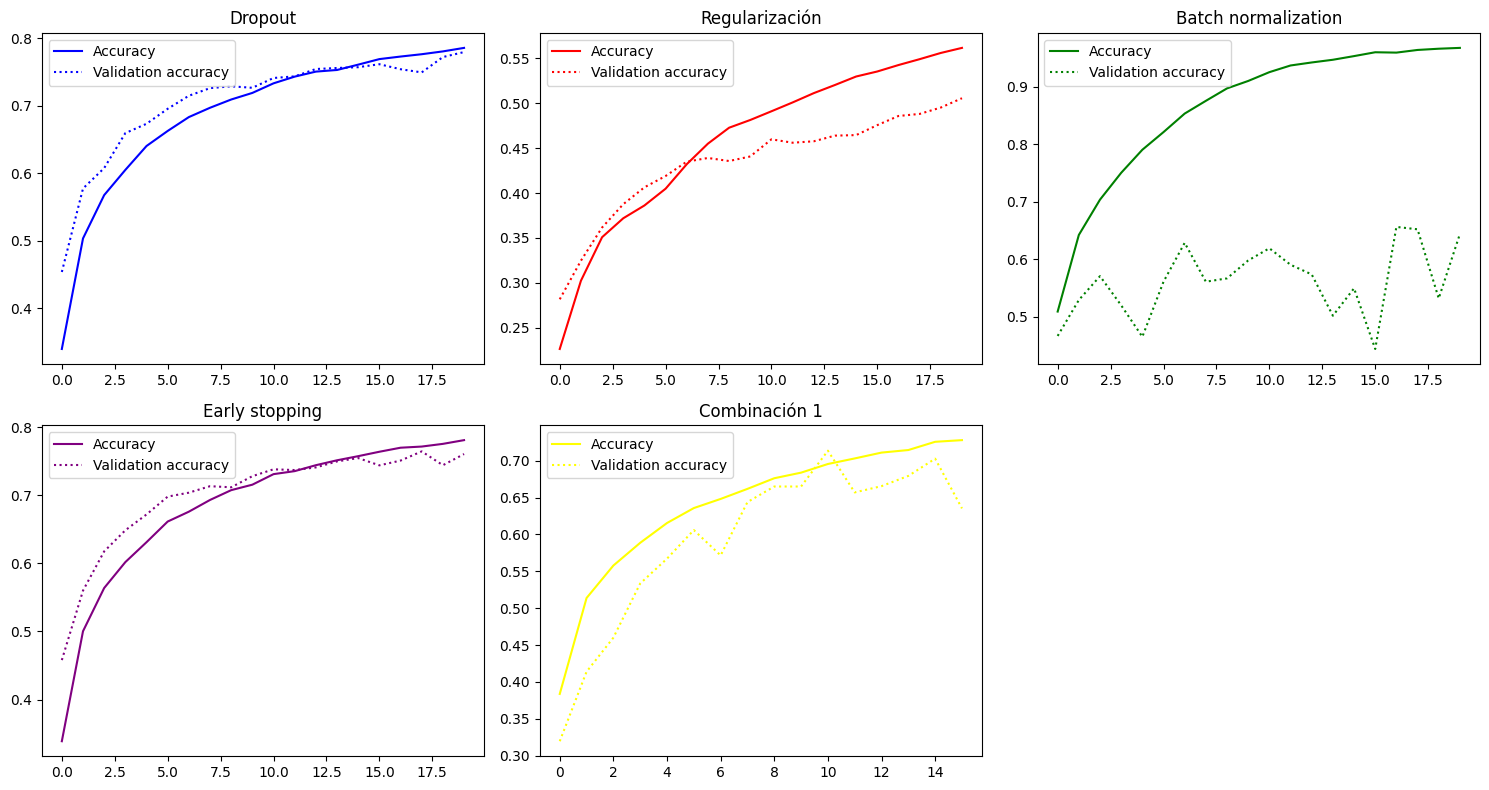

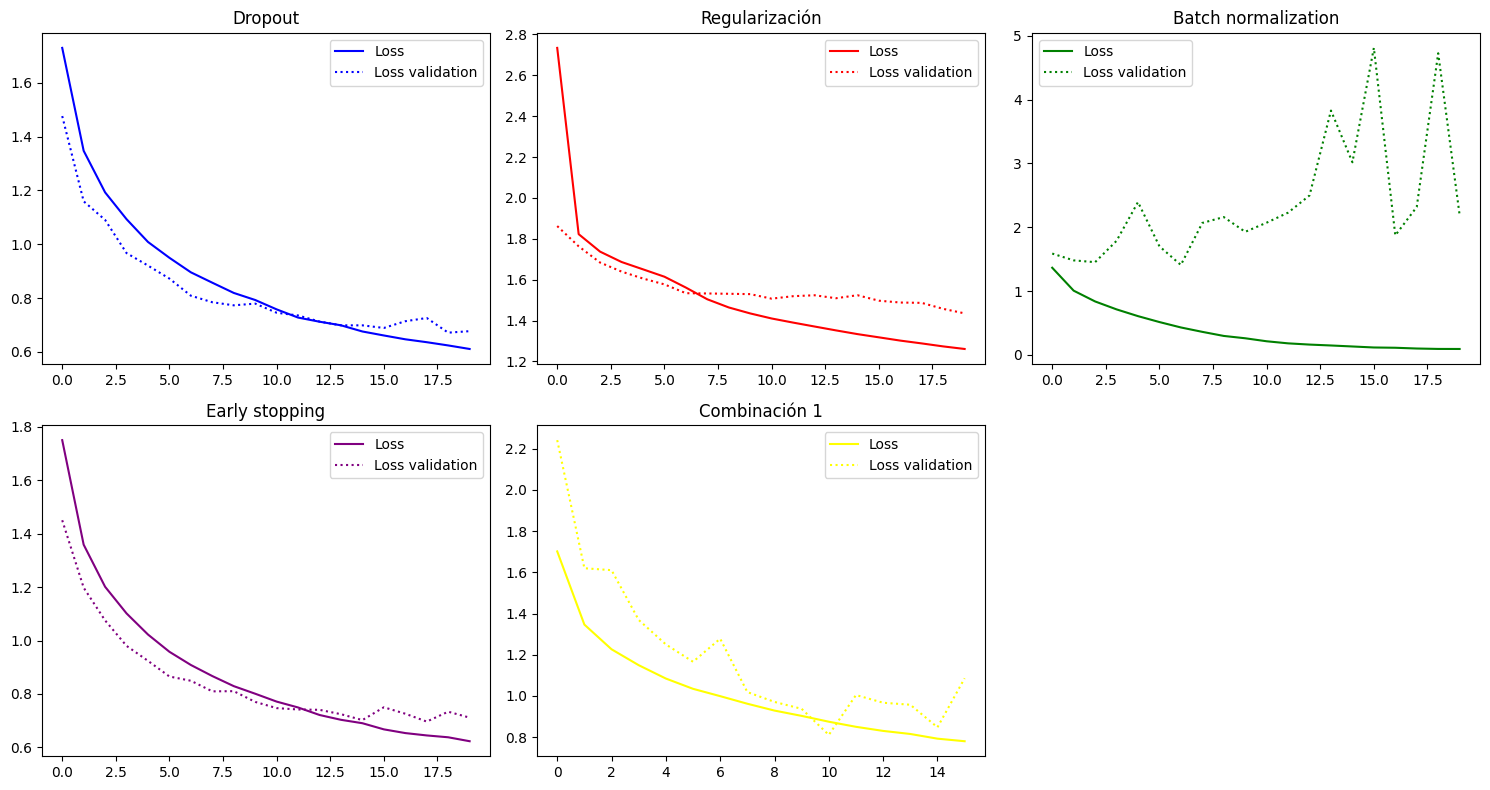

In [ ]:
Plot_All_Performance(lst_acc, lst_val_acc, lst_loss, lst_val_loss, lst_exp)

# Evaluación de los modelos

Para comparar los modelos, se calcularán las métricas de desempeño sobre el conjunto de prueba. Para las métricas *precision*, *recall* y *F1-score* se empleará la opción ***average="weighted"***, la cual calcula cada métrica de forma individual para cada clase y posteriormente obtiene un promedio ponderado según el número de instancias reales de cada clase.

Los resultados obtenidos para cada modelo se integrarán en un DataFrame para facilitar su comparación.

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
lst_preds = []

In [ ]:
# Modelo inicial
pred_ini = model.predict(X_test)
pred_ini = np.argmax(pred_ini, axis = 1)
lst_preds.append(('Inicial', pred_ini))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [ ]:
# Modelo con capa dropout
pred_dropout = model1.predict(X_test)
pred_dropout = np.argmax(pred_dropout, axis = 1)
lst_preds.append(('Dropout', pred_dropout))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
# Modelo con regularización
pred_L2 = model2.predict(X_test)
pred_L2 = np.argmax(pred_L2, axis = 1)
lst_preds.append(('Regularización', pred_L2))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [ ]:
# Modelo con Batch Normalization
pred_bn = model3.predict(X_test)
pred_bn = np.argmax(pred_bn, axis = 1)
lst_preds.append(('Batch Normalization', pred_bn))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [ ]:
# Modelo con early stopping
pred_early = model4.predict(X_test)
pred_early = np.argmax(pred_early, axis = 1)
lst_preds.append(('Early stopping', pred_early))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [ ]:
# Modelo combinado
pred_cmb = model5.predict(X_test)
pred_cmb = np.argmax(pred_cmb, axis = 1)
lst_preds.append(('Combinado', pred_cmb))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [ ]:
metrics = []

for nombre, y_pred in lst_preds:
    metrics.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average="weighted"),
        "Recall": recall_score(y_test, y_pred, average="weighted"),
        "F1": f1_score(y_test, y_pred, average="weighted")
    })

df_metrics = pd.DataFrame(metrics)

In [ ]:
df_metrics

,Modelo,Accuracy,Precision,Recall,F1
0,Inicial,0.7056,0.741585,0.7056,0.708402
1,Dropout,0.7697,0.770626,0.7697,0.768672
2,Batch Normalization,0.5023,0.531906,0.5023,0.476115
3,Regularización,0.6427,0.706378,0.6427,0.647568
4,Early stopping,0.7590,0.769149,0.7590,0.758852
5,Combinado,0.6339,0.716016,0.6339,0.630598


# Análisis visual de predicciones con el mejor modelo

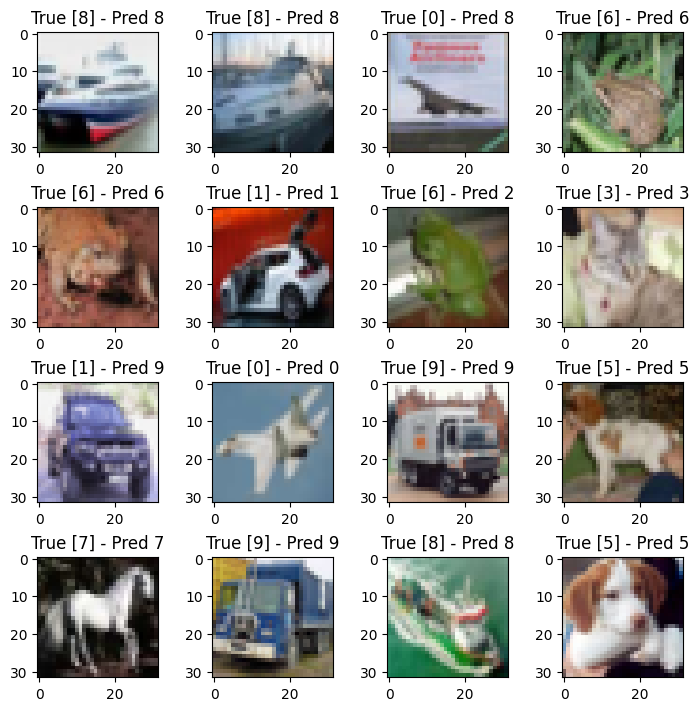

In [ ]:
# Tamaño de la figura
w = 7
h = 7

# Número de columnas y filas del subplot
cols = 4
rows = 4

# Creación de la figura
fig = plt.figure(figsize=(w, h), constrained_layout=True)

for i in range(1, cols*rows+1):
  img = X_test[i]
  ax = fig.add_subplot(rows, cols, i)
  plt.imshow(img, cmap="gray")
  ax.title.set_text('True ' + str(y_test[i])+' - Pred '+str(pred_dropout[i]))
plt.show()

# Ejercicio

Calcular la matriz de confusión del mejor modelo e identificar las clases en las que presenta mayor confusión. Analizar y determinar las posibles causas de estas confusiones.